In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
# Load the CSV file
df = pd.read_csv('POWER_Point_Daily_20250101_20251012_010d51N_000d37W_LST.csv', 
                 skiprows=20, 
                 na_values=-999)

# Display basic information
print("Data Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()


Data Shape: (285, 13)

Columns:
['YEAR', 'MO', 'DY', 'CLRSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DWN', 'WS2M', 'T2M', 'QV2M', 'PS', 'ALLSKY_SFC_SW_DNI', 'ALLSKY_SFC_SW_DIFF', 'PSC', 'WSC']

Data Types:
YEAR                    int64
MO                      int64
DY                      int64
CLRSKY_SFC_SW_DWN     float64
ALLSKY_SFC_SW_DWN     float64
WS2M                  float64
T2M                   float64
QV2M                  float64
PS                    float64
ALLSKY_SFC_SW_DNI     float64
ALLSKY_SFC_SW_DIFF    float64
PSC                   float64
WSC                   float64
dtype: object

First 5 rows:


,YEAR,MO,DY,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,WS2M,T2M,QV2M,PS,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DIFF,PSC,WSC
0,2025,1,1,5.2322,5.1758,2.22,24.73,10.19,98.77,3.1531,2.9280,92.28,2.48
1,2025,1,2,5.1151,4.9694,2.66,24.49,10.17,98.76,2.8987,2.6472,92.27,2.95
2,2025,1,3,5.0753,5.0731,2.79,24.20,9.57,98.88,2.6090,3.0794,92.37,3.04
3,2025,1,4,5.1972,5.1965,2.65,23.50,8.71,98.91,2.8579,3.0408,92.39,2.92
4,2025,1,5,5.6306,5.6285,2.44,23.92,8.82,98.84,4.5182,2.3628,92.33,2.85


## DATA PROCESSING

DATA PROCESSING

In [4]:
df['DATE'] = pd.to_datetime(df[['YEAR', 'MO', 'DY']].rename(
    columns={'YEAR': 'year', 'MO': 'month', 'DY': 'day'}))
df = df.set_index('DATE')

# Select numeric columns for analysis
numeric_cols = ['CLRSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DWN', 'WS2M', 'T2M', 
               'QV2M', 'PS', 'ALLSKY_SFC_SW_DNI', 'ALLSKY_SFC_SW_DIFF', 'PSC', 'WSC']
df_numeric = df[numeric_cols]

print("Data preprocessing completed!")
print(f"Date range: {df_numeric.index.min()} to {df_numeric.index.max()}")
print(f"Available parameters: {list(df_numeric.columns)}")

df_numeric.head()# Create datetime index# Create datetime index# Create datetime index# Create datetime index# Create datetime index# Create datetime index# Create datetime index


Data preprocessing completed!
Date range: 2025-01-01 00:00:00 to 2025-10-12 00:00:00
Available parameters: ['CLRSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DWN', 'WS2M', 'T2M', 'QV2M', 'PS', 'ALLSKY_SFC_SW_DNI', 'ALLSKY_SFC_SW_DIFF', 'PSC', 'WSC']


,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,WS2M,T2M,QV2M,PS,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DIFF,PSC,WSC
DATE,,,,,,,,,,
2025-01-01,5.2322,5.1758,2.22,24.73,10.19,98.77,3.1531,2.9280,92.28,2.48
2025-01-02,5.1151,4.9694,2.66,24.49,10.17,98.76,2.8987,2.6472,92.27,2.95
2025-01-03,5.0753,5.0731,2.79,24.20,9.57,98.88,2.6090,3.0794,92.37,3.04
2025-01-04,5.1972,5.1965,2.65,23.50,8.71,98.91,2.8579,3.0408,92.39,2.92
2025-01-05,5.6306,5.6285,2.44,23.92,8.82,98.84,4.5182,2.3628,92.33,2.85


## Basic Statistics

In [5]:
# Display basic statistics
print("BASIC STATISTICS:")
print("=" * 50)
df_numeric.describe()


BASIC STATISTICS:


,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,WS2M,T2M,QV2M,PS,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DIFF,PSC,WSC
count,180.000000,275.000000,282.000000,282.000000,282.000000,282.000000,180.000000,180.000000,282.000000,282.000000
mean,6.459257,5.354224,2.066773,27.869929,15.272979,98.814397,3.426589,2.782203,92.390816,2.117199
std,0.552587,1.242452,0.753070,2.687506,4.168973,0.202718,1.354275,0.410810,0.156629,0.693646
min,4.844900,0.332900,0.650000,21.560000,5.200000,98.280000,0.103700,1.405700,91.990000,0.680000
25%,6.078925,4.964150,1.430000,26.040000,14.385000,98.660000,2.485800,2.510375,92.280000,1.572500
50%,6.597450,5.674800,2.055000,27.290000,17.360000,98.860000,3.590400,2.811000,92.410000,2.090000
75%,6.875550,6.135400,2.625000,29.472500,18.100000,98.960000,4.377775,3.043550,92.510000,2.587500
max,7.412200,7.090800,4.020000,34.030000,20.520000,99.290000,6.209800,3.880300,92.790000,3.950000


## Missing Values Check

In [6]:
# Check for missing values
print("MISSING VALUES ANALYSIS:")
print("=" * 40)
missing_data = df_numeric.isnull().sum()
missing_percent = (missing_data / len(df_numeric)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
missing_df[missing_df['Missing Count'] > 0]


MISSING VALUES ANALYSIS:


,Missing Count,Missing Percentage
CLRSKY_SFC_SW_DWN,105,36.842105
ALLSKY_SFC_SW_DWN,10,3.508772
WS2M,3,1.052632
T2M,3,1.052632
QV2M,3,1.052632
PS,3,1.052632
ALLSKY_SFC_SW_DNI,105,36.842105
ALLSKY_SFC_SW_DIFF,105,36.842105
PSC,3,1.052632
WSC,3,1.052632


## Visualizations
CORRELATION

CORRELATION MATRIX


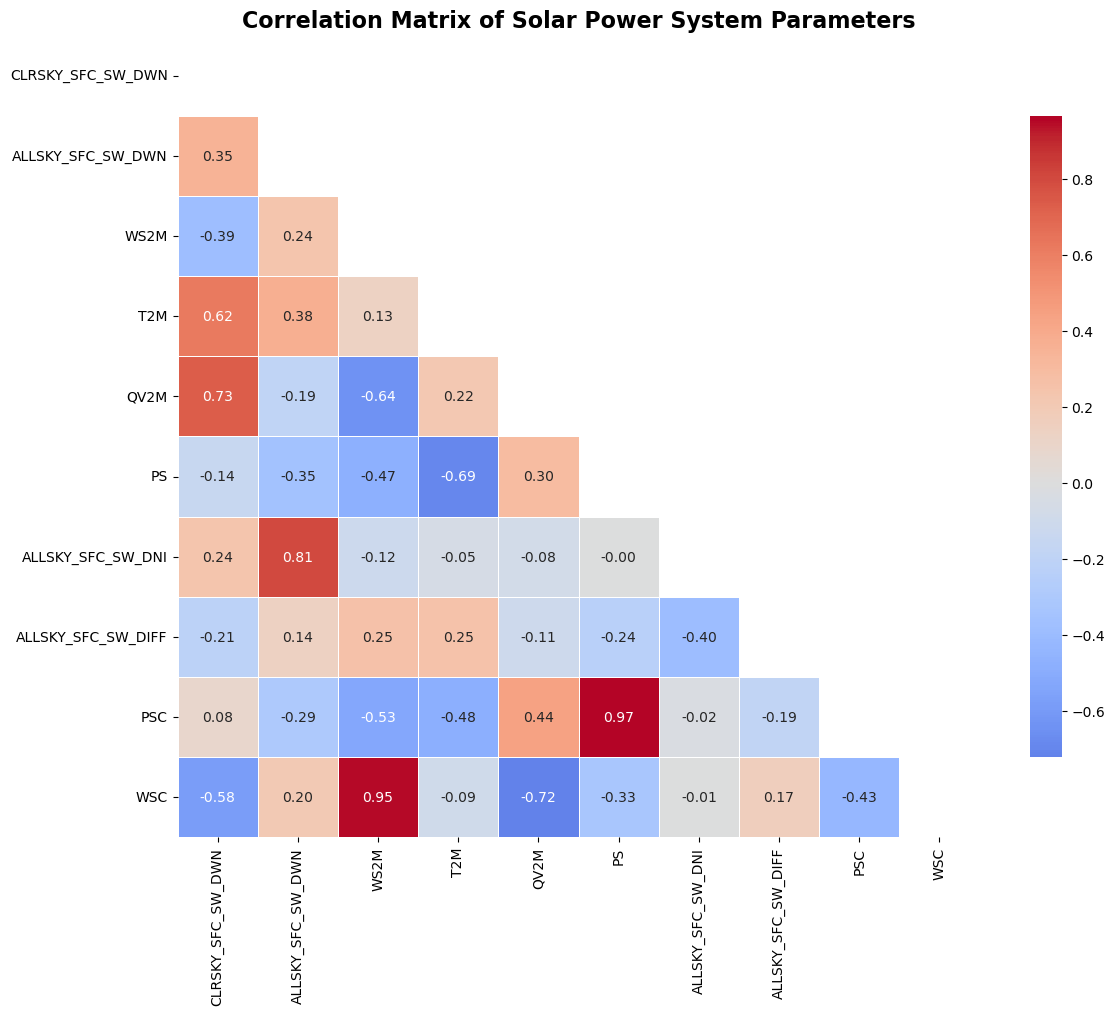


KEY CORRELATIONS WITH ALL SKY SOLAR RADIATION:
--------------------------------------------------
  ALLSKY_SFC_SW_DNI        : +0.807
  T2M                      : +0.377
  CLRSKY_SFC_SW_DWN        : +0.348
  WS2M                     : +0.240
  WSC                      : +0.204
  ALLSKY_SFC_SW_DIFF       : +0.138
  QV2M                     : -0.189
  PSC                      : -0.294
  PS                       : -0.354


In [7]:
# Correlation Matrix
print("CORRELATION MATRIX")
print("=" * 30)

plt.figure(figsize=(12, 10))
correlation_matrix = df_numeric.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Solar Power System Parameters', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Display key correlations with solar radiation
print("\nKEY CORRELATIONS WITH ALL SKY SOLAR RADIATION:")
print("-" * 50)
solar_correlations = correlation_matrix['ALLSKY_SFC_SW_DWN'].sort_values(ascending=False)
for param, corr in solar_correlations.items():
    if param != 'ALLSKY_SFC_SW_DWN':
        print(f"  {param:25}: {corr:+.3f}")


## TIME SERIES ANALYSIS

TIME SERIES ANALYSIS


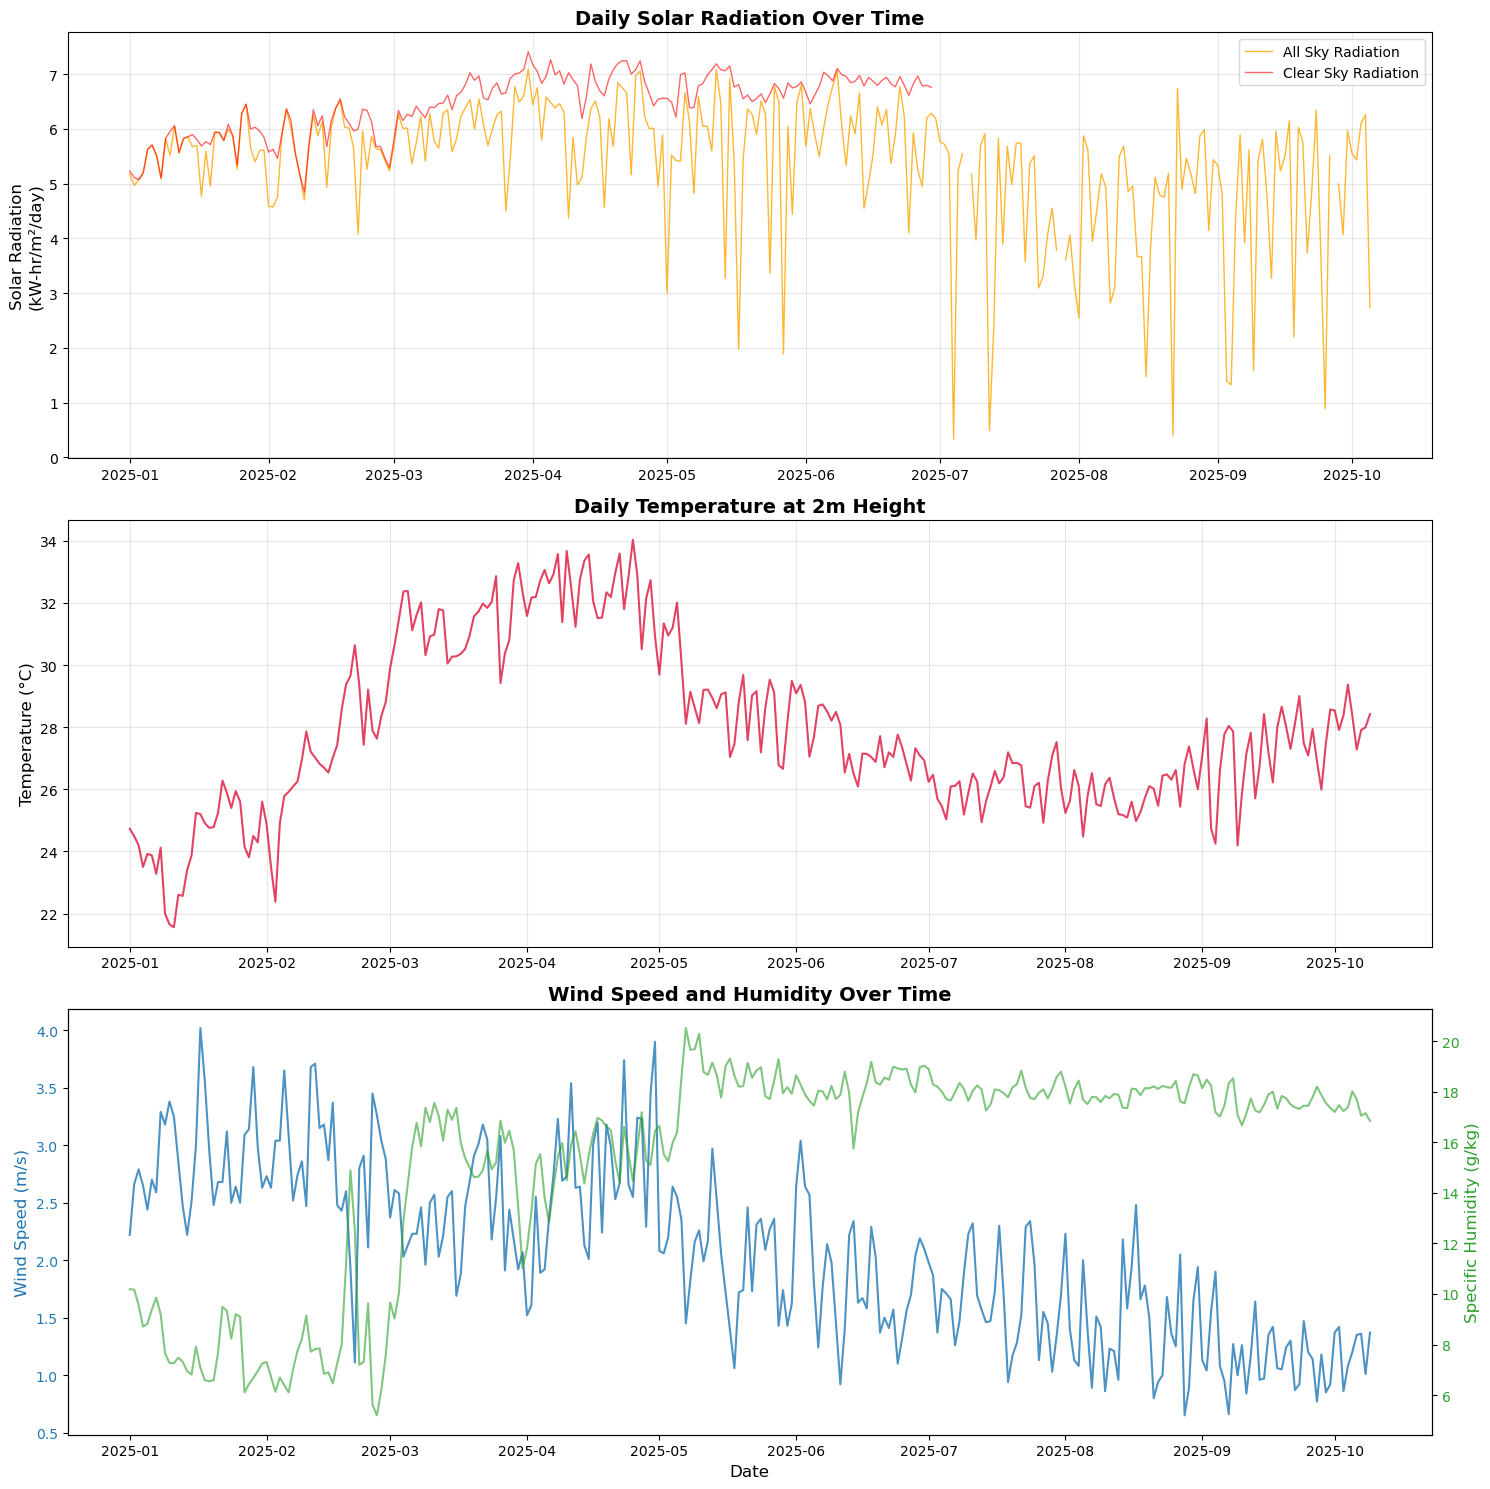

In [8]:
# Time Series Plots
print("TIME SERIES ANALYSIS")
print("=" * 25)

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

# 1. Solar Radiation
axes[0].plot(df_numeric.index, df_numeric['ALLSKY_SFC_SW_DWN'], 
             label='All Sky Radiation', color='orange', linewidth=1, alpha=0.8)
axes[0].plot(df_numeric.index, df_numeric['CLRSKY_SFC_SW_DWN'], 
             label='Clear Sky Radiation', color='red', linewidth=1, alpha=0.6)
axes[0].set_ylabel('Solar Radiation\n(kW-hr/m²/day)', fontsize=12)
axes[0].set_title('Daily Solar Radiation Over Time', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Temperature
axes[1].plot(df_numeric.index, df_numeric['T2M'], 
             color='crimson', linewidth=1.5, alpha=0.8)
axes[1].set_ylabel('Temperature (°C)', fontsize=12)
axes[1].set_title('Daily Temperature at 2m Height', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3. Wind Speed and Humidity
ax3 = axes[2]
color = 'tab:blue'
ax3.set_ylabel('Wind Speed (m/s)', color=color, fontsize=12)
ax3.plot(df_numeric.index, df_numeric['WS2M'], color=color, linewidth=1.5, alpha=0.8)
ax3.tick_params(axis='y', labelcolor=color)

ax3b = ax3.twinx()
color = 'tab:green'
ax3b.set_ylabel('Specific Humidity (g/kg)', color=color, fontsize=12)
ax3b.plot(df_numeric.index, df_numeric['QV2M'], color=color, linewidth=1.5, alpha=0.6)
ax3b.tick_params(axis='y', labelcolor=color)

axes[2].set_title('Wind Speed and Humidity Over Time', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=12)

plt.tight_layout()
plt.show()


## SCATTER PLOT WITH TREND LINES

SCATTER PLOTS WITH TREND LINES


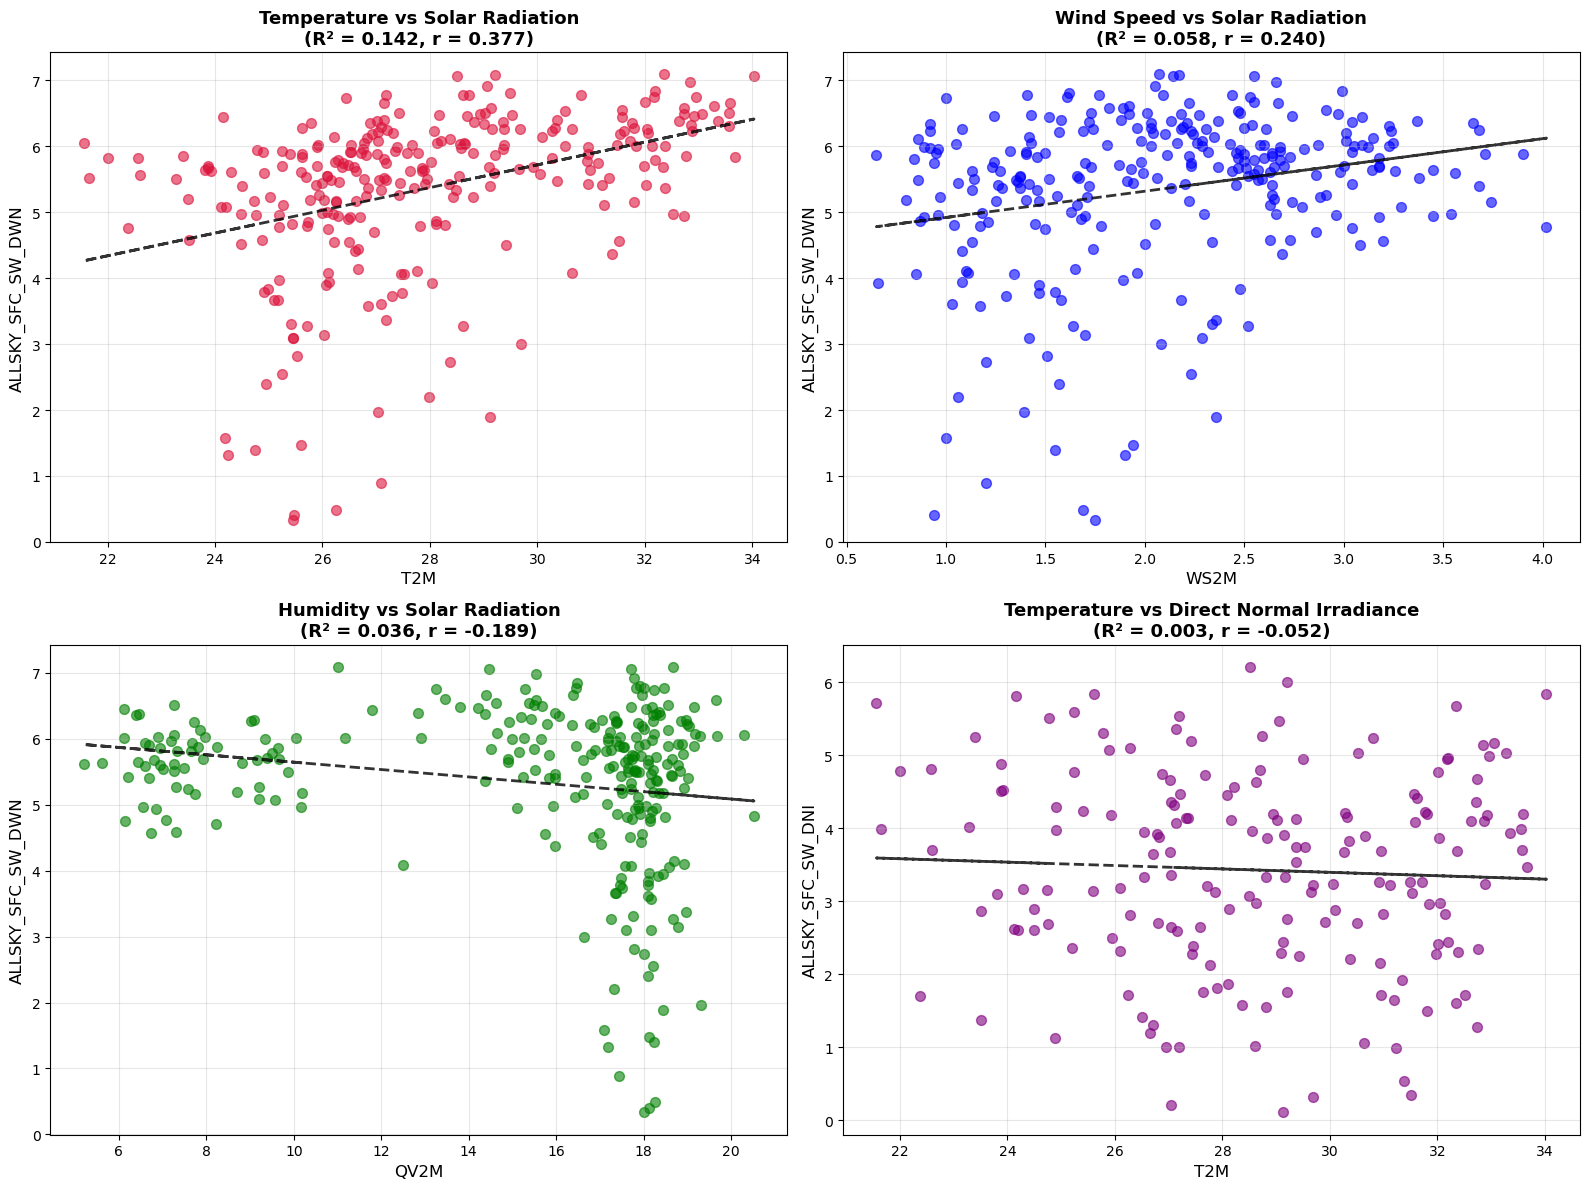

In [13]:
# Scatter Plots with Trend Lines
print("SCATTER PLOTS WITH TREND LINES")
print("=" * 35)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

relationships = [
    ('T2M', 'ALLSKY_SFC_SW_DWN', 'Temperature vs Solar Radiation', 'crimson'),
    ('WS2M', 'ALLSKY_SFC_SW_DWN', 'Wind Speed vs Solar Radiation', 'blue'),
    ('QV2M', 'ALLSKY_SFC_SW_DWN', 'Humidity vs Solar Radiation', 'green'),
    ('T2M', 'ALLSKY_SFC_SW_DNI', 'Temperature vs Direct Normal Irradiance', 'purple')
]

for i, (x_col, y_col, title, color) in enumerate(relationships):
    # Remove NaN values
    valid_data = df_numeric[[x_col, y_col]].dropna()
    
    if len(valid_data) > 1:
        # Scatter plot
        axes[i].scatter(valid_data[x_col], valid_data[y_col], alpha=0.6, color=color, s=50)
        
        # Trend line
        z = np.polyfit(valid_data[x_col], valid_data[y_col], 1)
        p = np.poly1d(z)
        axes[i].plot(valid_data[x_col], p(valid_data[x_col]), "k--", alpha=0.8, linewidth=2)
        
        # Calculate statistics
        r_squared = np.corrcoef(valid_data[x_col], valid_data[y_col])[0,1]**2
        correlation = np.corrcoef(valid_data[x_col], valid_data[y_col])[0,1]
        
        axes[i].set_xlabel(x_col, fontsize=12)
        axes[i].set_ylabel(y_col, fontsize=12)
        axes[i].set_title(f'{title}\n(R² = {r_squared:.3f}, r = {correlation:.3f})', 
                         fontsize=13, fontweight='bold')
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3D VISUALIZATION

3D RELATIONSHIP VISUALIZATION


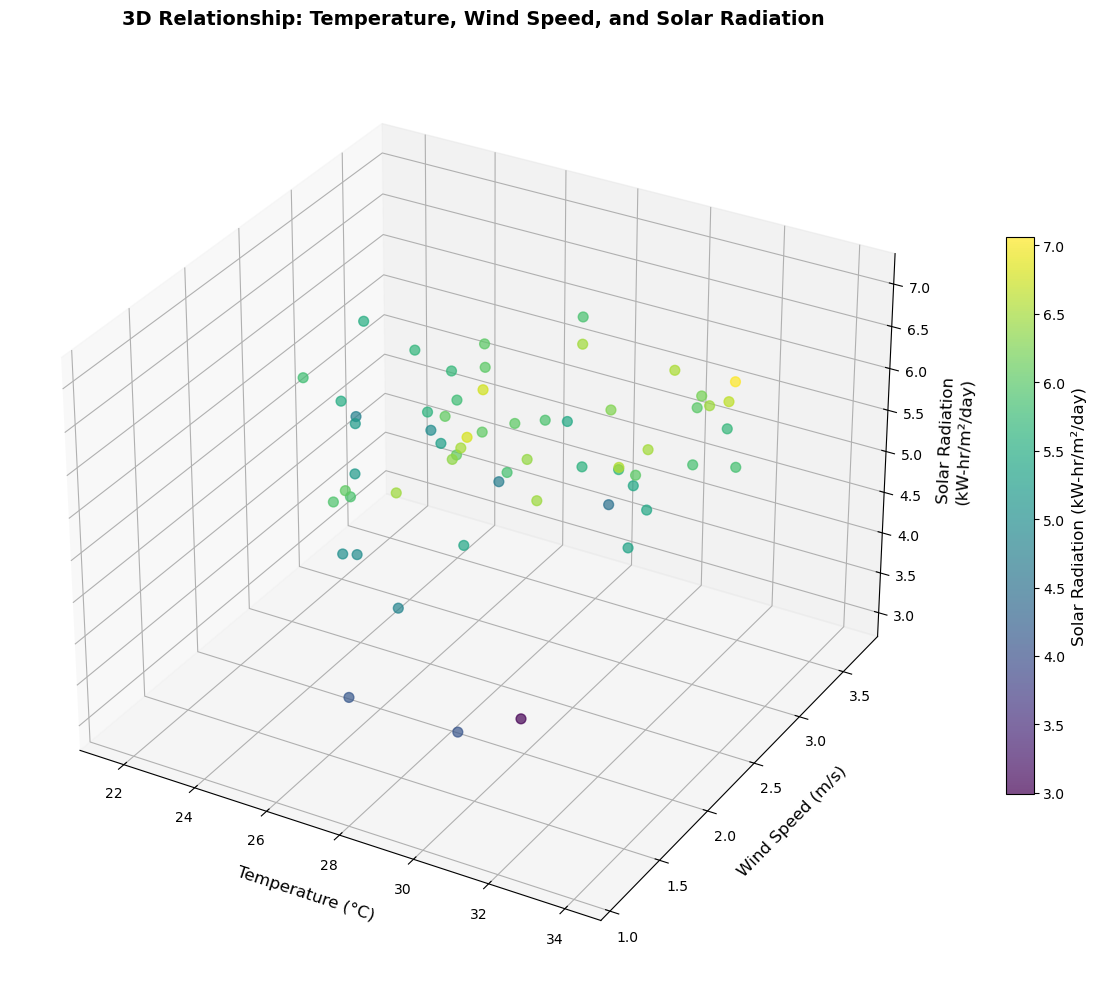

In [14]:
# 3D Scatter Plot
print("3D RELATIONSHIP VISUALIZATION")
print("=" * 35)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Use a sample for better visualization
sample_df = df_numeric.dropna().iloc[::3]  # Every 3rd point

# Create scatter plot
scatter = ax.scatter(sample_df['T2M'], sample_df['WS2M'], sample_df['ALLSKY_SFC_SW_DWN'],
                   c=sample_df['ALLSKY_SFC_SW_DWN'], cmap='viridis', 
                   s=50, alpha=0.7, depthshade=True)

ax.set_xlabel('Temperature (°C)', fontsize=12, labelpad=10)
ax.set_ylabel('Wind Speed (m/s)', fontsize=12, labelpad=10)
ax.set_zlabel('Solar Radiation\n(kW-hr/m²/day)', fontsize=12, labelpad=10)
ax.set_title('3D Relationship: Temperature, Wind Speed, and Solar Radiation', 
            fontsize=14, fontweight='bold', pad=20)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, aspect=20)
cbar.set_label('Solar Radiation (kW-hr/m²/day)', fontsize=12)

plt.tight_layout()
plt.show()


## SUMMARY AND INSIGHTS.
KEY FINDINGS

In [16]:
# Compute monthly statistics
df['DATE'] = pd.to_datetime(df[['YEAR', 'MO', 'DY']].rename(columns={'YEAR': 'year', 'MO': 'month', 'DY': 'day'}))
df_numeric = df.select_dtypes(include='number')
df_numeric['DATE'] = df['DATE']
df_numeric['MONTH'] = df['DATE'].dt.month

monthly_stats = df_numeric.groupby('MONTH').agg(['mean', 'std', 'min', 'max'])
correlation_matrix = df_numeric.drop(columns=['MONTH']).corr()

print("Monthly stats and correlation matrix ready.")

Monthly stats and correlation matrix ready.


In [17]:
# Summary of Key Insights
print("KEY FINDINGS SUMMARY")
print("=" * 25)

# Best month for solar radiation
best_month_idx = monthly_stats[('ALLSKY_SFC_SW_DWN', 'mean')].idxmax()
best_month_radiation = monthly_stats[('ALLSKY_SFC_SW_DWN', 'mean')].max()

print(f" Best month for solar radiation: Month {best_month_idx} ({best_month_radiation:.2f} kW-hr/m²/day)")

# Average conditions
avg_radiation = df_numeric['ALLSKY_SFC_SW_DWN'].mean()
avg_temperature = df_numeric['T2M'].mean()
avg_wind = df_numeric['WS2M'].mean()

print(f" Average solar radiation: {avg_radiation:.2f} kW-hr/m²/day")
print(f" Average temperature: {avg_temperature:.2f} °C")
print(f" Average wind speed: {avg_wind:.2f} m/s")

# Strongest correlations
strong_corrs = correlation_matrix['ALLSKY_SFC_SW_DWN'].abs().sort_values(ascending=False)
strong_corrs = strong_corrs[strong_corrs.index != 'ALLSKY_SFC_SW_DWN']

print(f"\n Strongest correlations with solar radiation:")
for i, (param, corr) in enumerate(strong_corrs.head(3).items()):
    actual_corr = correlation_matrix.loc['ALLSKY_SFC_SW_DWN', param]
    print(f"   {i+1}. {param}: {actual_corr:+.3f}")


KEY FINDINGS SUMMARY
 Best month for solar radiation: Month 4 (6.05 kW-hr/m²/day)
 Average solar radiation: 5.35 kW-hr/m²/day
 Average temperature: 27.87 °C
 Average wind speed: 2.07 m/s

 Strongest correlations with solar radiation:
   1. ALLSKY_SFC_SW_DNI: +0.807
   2. T2M: +0.377
   3. MO: -0.365
